# State Unemployment Rates — All US States (1976–present)
**Source:** FRED (mirrors BLS Local Area Unemployment Statistics)  
**Series:** `{STATE}UR` — monthly, seasonally adjusted unemployment rate  
**Coverage:** 50 states + DC, Jan 1976 – latest available

## 1. Setup

In [1]:
import os, time, requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FRED_API_KEY = os.getenv("FRED_API_KEY", "12d77a40907e43a92e9a295801db18d2")
FRED_URL     = "https://api.stlouisfed.org/fred/series/observations"

## 2. Fetch data

In [2]:
STATES = [
    ("Alabama",              "AL", "01"), ("Alaska",               "AK", "02"),
    ("Arizona",              "AZ", "04"), ("Arkansas",             "AR", "05"),
    ("California",           "CA", "06"), ("Colorado",             "CO", "08"),
    ("Connecticut",          "CT", "09"), ("Delaware",             "DE", "10"),
    ("District of Columbia", "DC", "11"), ("Florida",              "FL", "12"),
    ("Georgia",              "GA", "13"), ("Hawaii",               "HI", "15"),
    ("Idaho",                "ID", "16"), ("Illinois",             "IL", "17"),
    ("Indiana",              "IN", "18"), ("Iowa",                 "IA", "19"),
    ("Kansas",               "KS", "20"), ("Kentucky",             "KY", "21"),
    ("Louisiana",            "LA", "22"), ("Maine",                "ME", "23"),
    ("Maryland",             "MD", "24"), ("Massachusetts",        "MA", "25"),
    ("Michigan",             "MI", "26"), ("Minnesota",            "MN", "27"),
    ("Mississippi",          "MS", "28"), ("Missouri",             "MO", "29"),
    ("Montana",              "MT", "30"), ("Nebraska",             "NE", "31"),
    ("Nevada",               "NV", "32"), ("New Hampshire",        "NH", "33"),
    ("New Jersey",           "NJ", "34"), ("New Mexico",           "NM", "35"),
    ("New York",             "NY", "36"), ("North Carolina",       "NC", "37"),
    ("North Dakota",         "ND", "38"), ("Ohio",                 "OH", "39"),
    ("Oklahoma",             "OK", "40"), ("Oregon",               "OR", "41"),
    ("Pennsylvania",         "PA", "42"), ("Rhode Island",         "RI", "44"),
    ("South Carolina",       "SC", "45"), ("South Dakota",         "SD", "46"),
    ("Tennessee",            "TN", "47"), ("Texas",                "TX", "48"),
    ("Utah",                 "UT", "49"), ("Vermont",              "VT", "50"),
    ("Virginia",             "VA", "51"), ("Washington",           "WA", "53"),
    ("West Virginia",        "WV", "54"), ("Wisconsin",            "WI", "55"),
    ("Wyoming",              "WY", "56"),
]


def fetch_fred(series_id, retries=4):
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": "1976-01-01",
        "frequency": "m",
    }
    for attempt in range(retries):
        data = requests.get(FRED_URL, params=params, timeout=30).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1))
                continue
            raise ValueError(data["error_message"])
        return [o for o in data["observations"] if o["value"] != "."]
    raise RuntimeError(f"Rate limit persists for {series_id}")


rows, failed = [], []

for i, (name, abbr, fips) in enumerate(STATES):
    sid = f"{abbr}UR"
    try:
        obs = fetch_fred(sid)
        for o in obs:
            rows.append({"state": name, "abbr": abbr, "fips": fips,
                         "date": pd.to_datetime(o["date"]),
                         "unemployment_rate": float(o["value"])})
        print(f"[{i+1:2d}/51] {sid}  {len(obs)} obs  latest {obs[-1]['date'][:7]} = {obs[-1]['value']}%")
    except Exception as e:
        print(f"[{i+1:2d}/51] {sid}  FAILED — {e}")
        failed.append(sid)
    time.sleep(0.3)

if failed:
    print(f"\n⚠ Failed series: {failed}")

df = pd.DataFrame(rows).sort_values(["state", "date"]).reset_index(drop=True)
print(f"\n{len(df):,} rows  |  {df['state'].nunique()} states  |  {df['date'].min().date()} – {df['date'].max().date()}")
df.head()

[ 1/51] ALUR  603 obs  latest 2026-04 = 2.8%
[ 2/51] AKUR  603 obs  latest 2026-04 = 4.7%
[ 3/51] AZUR  603 obs  latest 2026-04 = 4.7%
[ 4/51] ARUR  603 obs  latest 2026-04 = 4.3%
[ 5/51] CAUR  603 obs  latest 2026-04 = 5.3%
[ 6/51] COUR  603 obs  latest 2026-04 = 3.9%
[ 7/51] CTUR  603 obs  latest 2026-04 = 5.0%
[ 8/51] DEUR  603 obs  latest 2026-04 = 5.3%
[ 9/51] DCUR  603 obs  latest 2026-04 = 6.2%
[10/51] FLUR  603 obs  latest 2026-04 = 4.8%
[11/51] GAUR  603 obs  latest 2026-04 = 3.5%
[12/51] HIUR  603 obs  latest 2026-04 = 2.5%
[13/51] IDUR  603 obs  latest 2026-04 = 3.6%
[14/51] ILUR  603 obs  latest 2026-04 = 5.1%
[15/51] INUR  603 obs  latest 2026-04 = 3.2%
[16/51] IAUR  603 obs  latest 2026-04 = 3.3%
[17/51] KSUR  603 obs  latest 2026-04 = 3.9%
[18/51] KYUR  603 obs  latest 2026-04 = 4.3%
[19/51] LAUR  603 obs  latest 2026-04 = 4.4%
[20/51] MEUR  603 obs  latest 2026-04 = 3.1%
[21/51] MDUR  603 obs  latest 2026-04 = 4.4%
[22/51] MAUR  603 obs  latest 2026-04 = 4.7%
[23/51] MI

,state,abbr,fips,date,unemployment_rate
0,Alabama,AL,01,1976-01-01,6.7
1,Alabama,AL,01,1976-02-01,6.6
2,Alabama,AL,01,1976-03-01,6.6
3,Alabama,AL,01,1976-04-01,6.5
4,Alabama,AL,01,1976-05-01,6.4


## 3. Reshape & save

In [3]:
# Wide format: rows = dates, columns = states
wide = df.pivot(index="date", columns="state", values="unemployment_rate").sort_index()
wide.index.name = "date"
print(f"Wide shape: {wide.shape}")
wide.tail()

Wide shape: (603, 51)


state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,District of Columbia,Florida,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2025-12-01,2.7,4.8,4.4,4.3,5.5,3.8,4.3,5.3,6.7,4.3,...,2.2,3.6,4.3,3.7,2.7,3.6,4.9,4.6,3.2,3.5
2026-01-01,2.7,4.8,4.5,4.4,5.4,3.9,4.5,5.4,6.7,4.5,...,2.2,3.5,4.3,3.8,2.7,3.7,5.0,4.6,3.3,3.6
2026-02-01,2.7,4.7,4.6,4.4,5.4,3.9,4.7,5.4,6.5,4.6,...,2.3,3.6,4.3,3.8,2.6,3.8,5.1,4.7,3.4,3.6
2026-03-01,2.7,4.7,4.7,4.3,5.3,3.9,4.8,5.4,6.3,4.7,...,2.3,3.6,4.3,3.8,2.6,3.8,5.1,4.5,3.5,3.6
2026-04-01,2.8,4.7,4.7,4.3,5.3,3.9,5.0,5.3,6.2,4.8,...,2.2,3.6,4.3,3.8,2.6,3.8,5.2,4.4,3.5,3.5


In [4]:
df.to_csv("state_unemployment_long.csv", index=False)
wide.to_csv("state_unemployment_wide.csv")
print("Saved state_unemployment_long.csv  and  state_unemployment_wide.csv")

Saved state_unemployment_long.csv  and  state_unemployment_wide.csv


## 4. Visualizations

In [5]:
# Pre-compute cross-state stats used in multiple plots
median = wide.median(axis=1)
q25    = wide.quantile(0.25, axis=1)
q75    = wide.quantile(0.75, axis=1)
pct_fmt = mticker.FormatStrFormatter("%.1f%%")

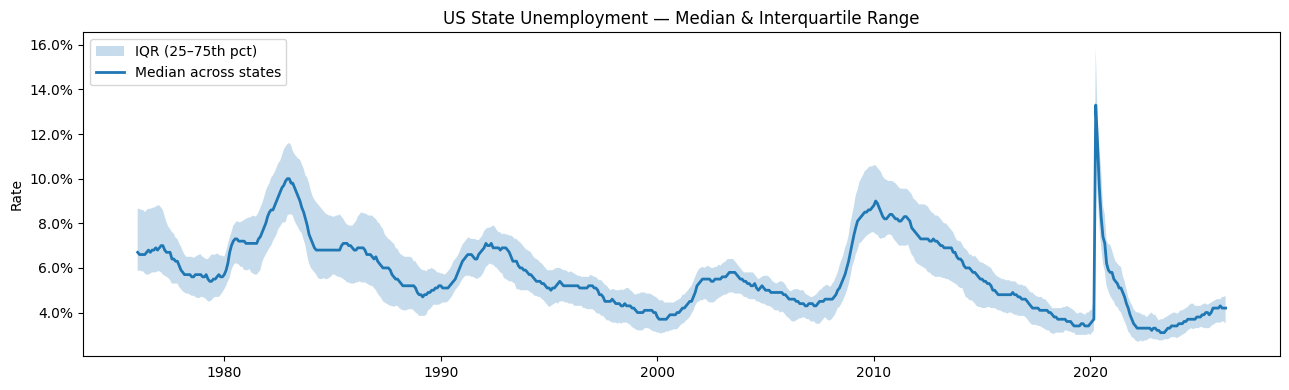

In [6]:
# ── Plot 1: Median + IQR band over time ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(wide.index, q25, q75, alpha=0.25, label="IQR (25–75th pct)")
ax.plot(wide.index, median, lw=2, label="Median across states")
ax.set_title("US State Unemployment — Median & Interquartile Range")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(pct_fmt)
ax.legend()
plt.tight_layout()
plt.show()

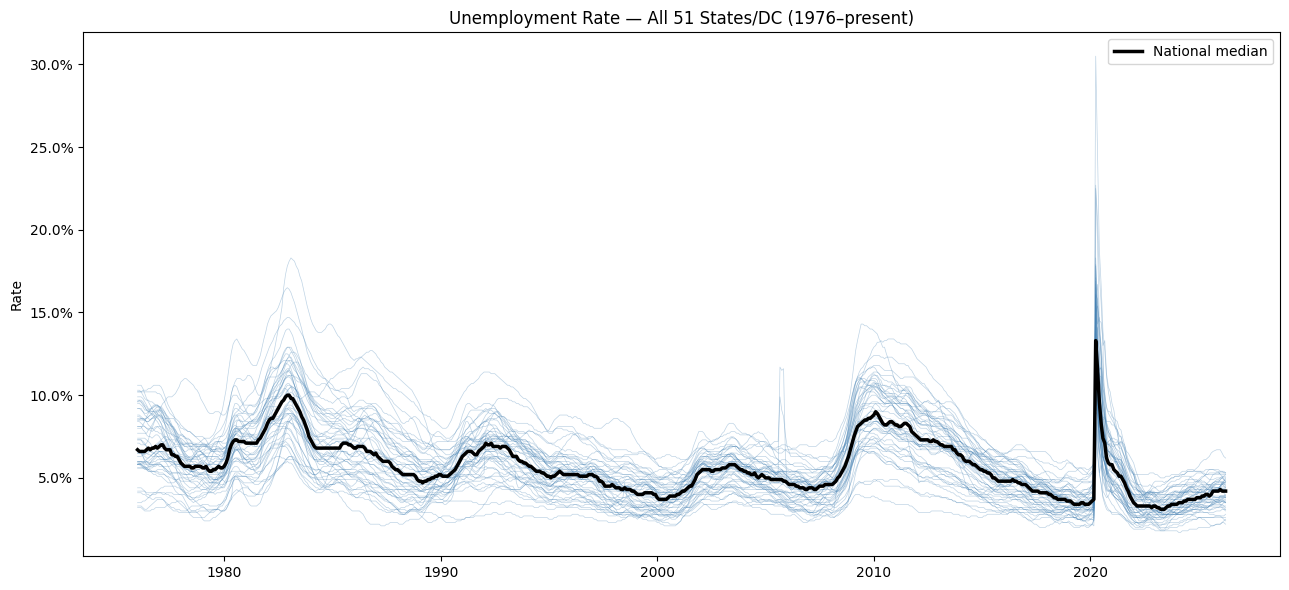

In [7]:
# ── Plot 2: Spaghetti — all states ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
for col in wide.columns:
    ax.plot(wide.index, wide[col], lw=0.5, alpha=0.35, color="steelblue")
ax.plot(wide.index, median, lw=2.5, color="black", label="National median")
ax.set_title("Unemployment Rate — All 51 States/DC (1976–present)")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(pct_fmt)
ax.legend()
plt.tight_layout()
plt.show()

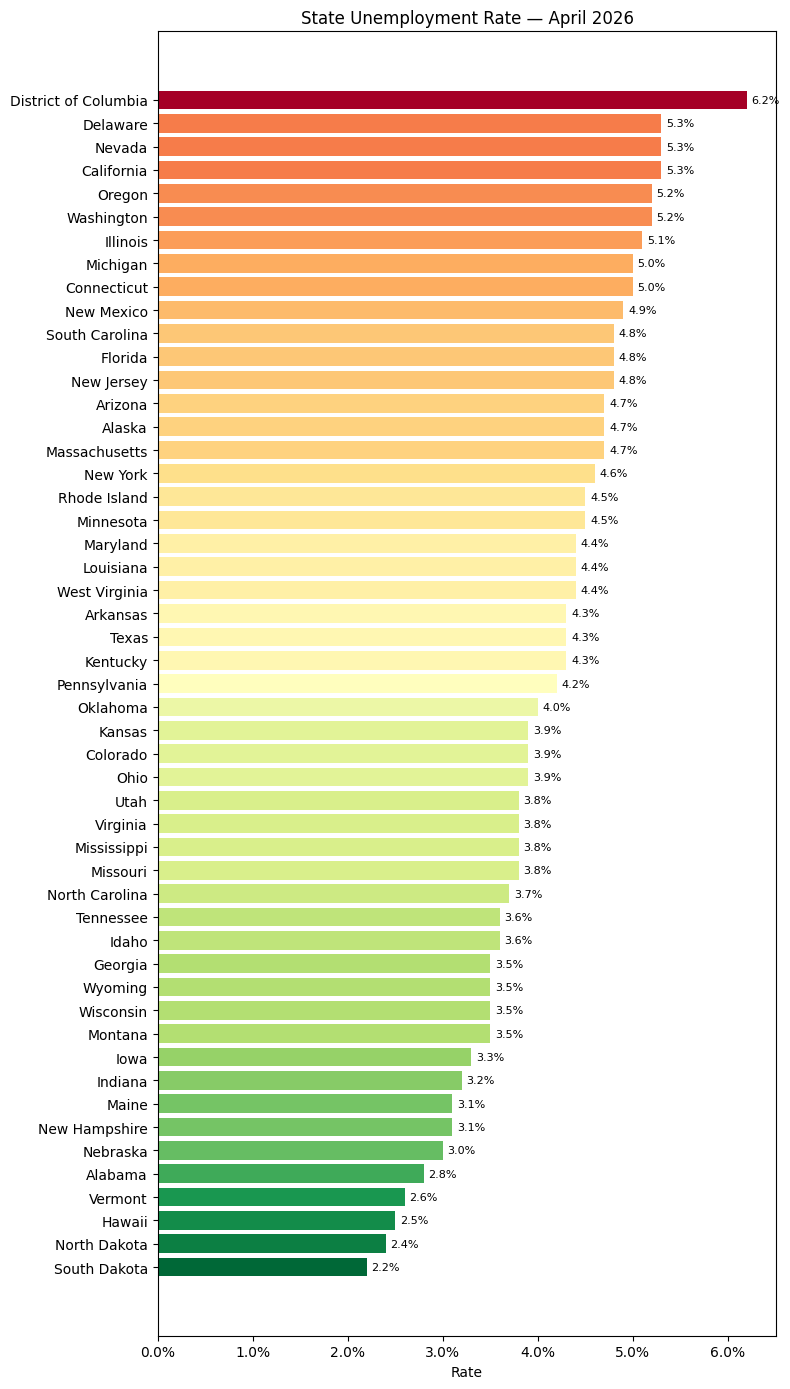

In [8]:
# ── Plot 3: Latest month — ranked bar chart ───────────────────────────────────
latest    = wide.iloc[-1].sort_values(ascending=True)
latest_dt = wide.index[-1].strftime("%B %Y")
norm      = plt.Normalize(latest.min(), latest.max())
colors    = plt.cm.RdYlGn_r([norm(v) for v in latest.values])

fig, ax = plt.subplots(figsize=(8, 14))
bars = ax.barh(latest.index, latest.values, color=colors)
for bar, val in zip(bars, latest.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.set_title(f"State Unemployment Rate — {latest_dt}")
ax.set_xlabel("Rate")
ax.xaxis.set_major_formatter(pct_fmt)
plt.tight_layout()
plt.show()

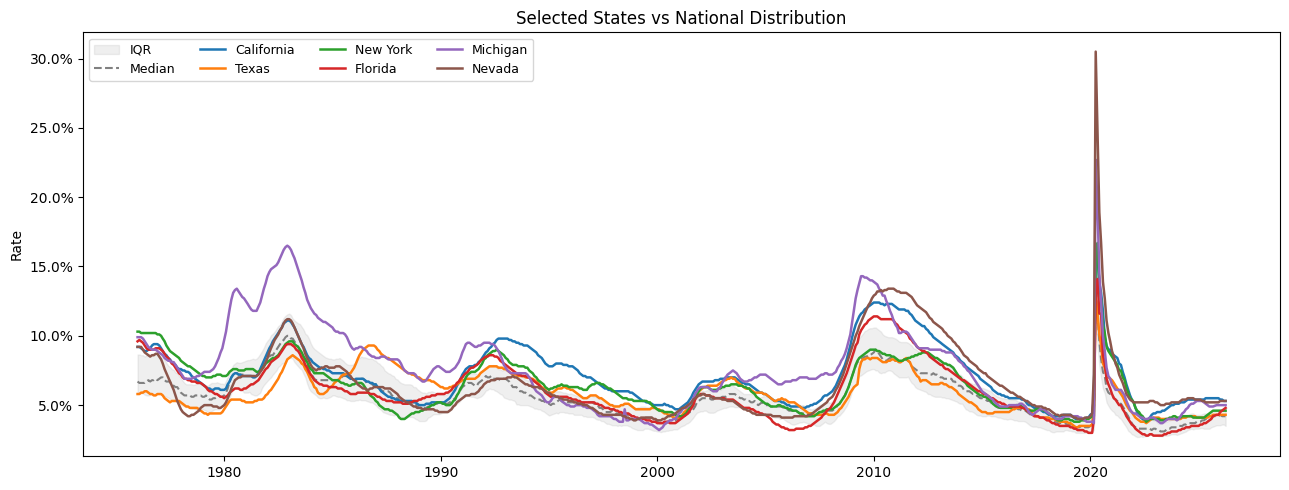

In [10]:
# ── Plot 4: Selected states vs distribution ───────────────────────────────────
HIGHLIGHT = ["California", "Texas", "New York", "Florida", "Michigan", "Nevada"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(wide.index, q25, q75, alpha=0.12, color="gray", label="IQR")
ax.plot(wide.index, median, lw=1.5, color="gray", ls="--", label="Median")
for state in HIGHLIGHT:
    ax.plot(wide.index, wide[state], lw=1.8, label=state)
ax.set_title("Selected States vs National Distribution")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(pct_fmt)
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

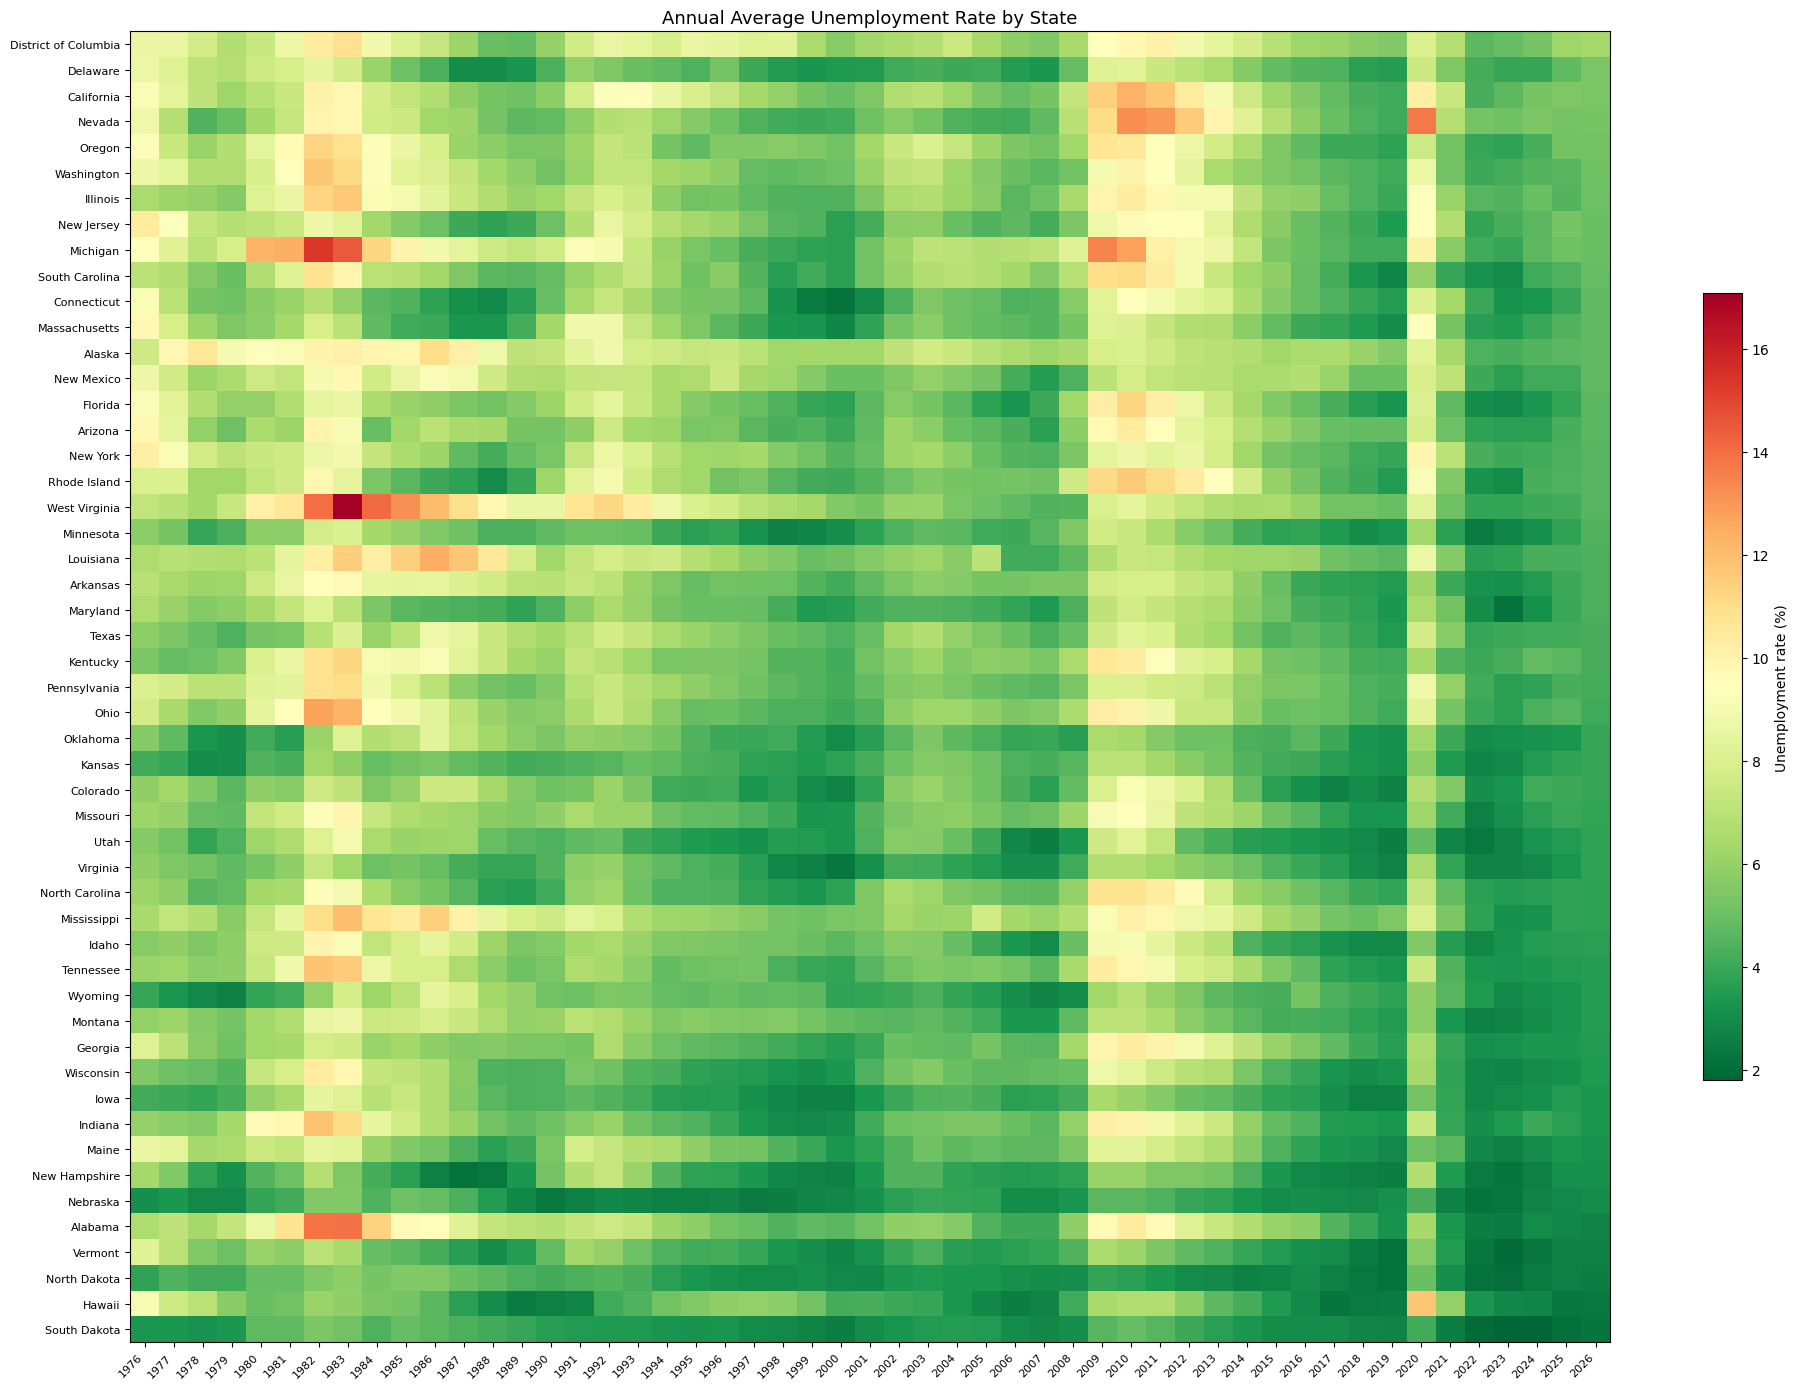

In [11]:
# ── Plot 5: Heatmap — state × year (annual average) ──────────────────────────
annual = df.assign(year=df["date"].dt.year)
heat   = annual.groupby(["state", "year"])["unemployment_rate"].mean().unstack("year")
heat   = heat.sort_values(heat.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(20, 14))
im = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
plt.colorbar(im, ax=ax, label="Unemployment rate (%)", shrink=0.6)
ax.set_title("Annual Average Unemployment Rate by State", fontsize=13)
plt.tight_layout()
plt.show()